
# Exploration du corpus KALLAAMA — Wolof

> **Objectif** — Auditer le checked set wolof de KALLAAMA (36 fichiers)
> comme donnée d'entraînement ASR : parsing des `.stm`, conventions
> d'annotation, biais, code-switching. Produire un corpus nettoyé et
> documenté (`corpus_clean.csv`) qui alimente le notebook de test ASR.
>
> **Livrables**
> - `notebooks/01_kallaama_exploration.ipynb` — cet audit
> - `src/kallaama.py` — module de parsing, nettoyage et chargement (importé ici)
> - `corpus_clean.csv` — les 11 098 segments de parole, nettoyés et annotés,
>   entrée du notebook de test ASR

---

## Le corpus

**KALLAAMA** — *A Transcribed Speech Dataset about Agriculture in the Three Most
Widely Spoken Languages in Senegal* (production 2023, publication RAIL 2024).

Thématique **agriculture** :

| | |
|---|---|
| **Porteur** | Jokalante (Dakar) |
| **Partenaires** | Orange Innovation (Lannion), École Polytechnique de Thiès |
| **Financement** | Lacuna Fund |
| **Langues** | wolof (`wol`), pulaar (`fuc`), sereer (`srr`) |
| **Audio** | WAV, 16 kHz, 16 bits, mono |
| **Transcriptions** | `.stm` (NIST) — **format retenu** · `.trs` (Transcriber XML) — métadonnées locuteur |
| **Licence** | CC-BY 4.0 — usage commercial, modification et redistribution autorisés, sous réserve d'attribution |

Ce notebook caractérise le corpus **comme donnée d'entraînement**. La
publication met à disposition les données et leurs annotations, mais
laisse à l'utilisateur toute la méthode qui les rend exploitables pour du
fine-tuning ASR : quels segments retenir, comment normaliser les
transcriptions, comment mesurer le code-switching, quelles zones exclure
de l'évaluation. C'est cette chaîne — de la donnée brute au corpus
mesurable — que le notebook établit.

## 0 — Setup
Import du module, chargement du corpus depuis les .stm.

In [40]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path(r"C:\dev\noo-far-pipeline")
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from kallaama import load_corpus, extract_segment

CHECKED_DIR = PROJECT_ROOT / "data" / "kallaama" / "wolof" / "speech_dataset" / "checked_transcriptions"

df, stats = load_corpus(CHECKED_DIR)

In [1]:
import numpy as np
from pathlib import Path
import pandas as pd
import re
from collections import Counter
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display


## 1 — Test de non-régression
Vérifier que le chargement reproduit les chiffres mesurés à la main.
Les `assert` font échouer le notebook si le corpus ou le module change.

In [41]:
# Chiffres établis manuellement pendant l'audit (voir sections suivantes)
assert stats["lignes_lues"]      == 13061, stats["lignes_lues"]
assert stats["segments_retenus"] == 11098, stats["segments_retenus"]
assert stats["rejet_sans_texte"] ==   465, stats["rejet_sans_texte"]
assert stats["rejet_exclus"]     ==  1484, stats["rejet_exclus"]
assert stats["rejet_bornes"]     ==    14, stats["rejet_bornes"]

assert len(df)               == 11098
assert df["file"].nunique()  == 36

print("Non-régression OK :", dict(stats))

Non-régression OK : {'lignes_lues': 13061, 'segments_retenus': 11098, 'rejet_sans_texte': 465, 'rejet_exclus': 1484, 'rejet_bornes': 14}


## 2 — Volumétrie et rejets
Du fichier brut au corpus évaluable : 13 061 lignes → 11 098 segments de
parole → 6 960 évaluables. Où passent les lignes écartées.

In [42]:
volumetrie = pd.DataFrame(
    {
        "lignes": [
            stats["lignes_lues"],
            stats["segments_retenus"],
            stats["rejet_exclus"],
            stats["rejet_sans_texte"],
            stats["rejet_bornes"],
        ]
    },
    index=[
        "Lignes lues",
        "→ Segments de parole retenus",
        "Rejet : zones exclues (excluded_region)",
        "Rejet : lignes sans texte (inter_segment_gap)",
        "Rejet : bornes dégénérées (durée nulle)",
    ],
)
volumetrie["% des lignes"] = (100 * volumetrie["lignes"] / stats["lignes_lues"]).round(1)
volumetrie

,lignes,% des lignes
Lignes lues,13061,100.0
→ Segments de parole retenus,11098,85.0
Rejet : zones exclues (excluded_region),1484,11.4
Rejet : lignes sans texte (inter_segment_gap),465,3.6
Rejet : bornes dégénérées (durée nulle),14,0.1


Les 1 484 `excluded_region` sont des intervalles que le protocole NIST
exclut du scoring (musique, silence, parole inintelligible). Non filtrés,
ils entrent dans les références WER avec leur pseudo-texte
`ignore_time_segment_in_scoring` — soit ~1 500 fausses références. C'est le
principal écart avec un parsing naïf, qui retiendrait 12 596 lignes au lieu
de 11 098.

## 3 — Statistiques du corpus
Durées, genre, condition acoustique, locuteurs. Sur les segments utiles.

In [46]:
utiles = df[df["usable"]]

print("Durées de segment (segments utilisables) :")
print(f"  médiane   : {utiles['duration'].median():.1f}s")
print(f"  p25 / p75 : {utiles['duration'].quantile(.25):.1f}s / {utiles['duration'].quantile(.75):.1f}s")
print(f"  min / max : {utiles['duration'].min():.1f}s / {utiles['duration'].max():.1f}s")

Durées de segment (segments utilisables) :
  médiane   : 2.7s
  p25 / p75 : 1.3s / 6.4s
  min / max : 0.1s / 102.9s


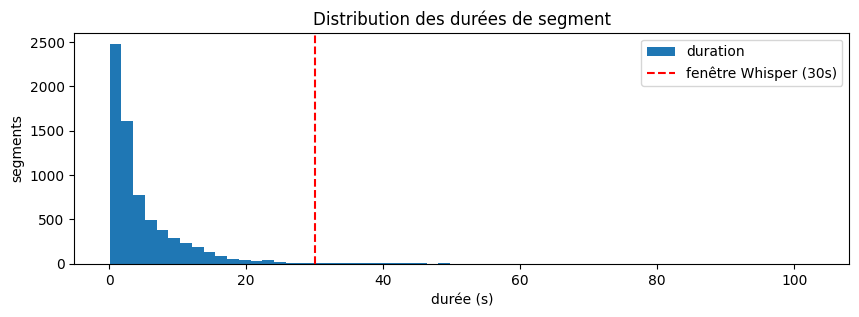

: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))
utiles["duration"].plot.hist(bins=60)
plt.axvline(30, color="red", linestyle="--", label="fenêtre Whisper (30s)")
plt.xlabel("durée (s)"); plt.ylabel("segments"); plt.legend()
plt.title("Distribution des durées de segment")
plt.show()

In [ ]:
print("Genre     :", utiles["genre"].value_counts().to_dict())
print("Condition :", utiles["condition"].value_counts().to_dict())
print("Locuteurs :", utiles["speaker"].nunique(), "distincts")

Genre     : {'male': 5969, 'female': 798, 'unknown': 191, '': 2}
Condition : {'f1': 3553, 'f0': 3407}
Locuteurs : 12 distincts


: 

Le corpus est fortement déséquilibré en genre (~84 % masculin) : les
intervenants sont majoritairement des experts et animateurs hommes, la
parole féminine se limitant souvent au backchannel. À documenter comme
limite — l'assistant Ñoo Far s'adresse aussi à des éleveuses.

La durée médiane (~1,4 s) contre la fenêtre de 30 s de Whisper impose un
regroupement des segments avant fine-tuning (traité au notebook 2).

## 4 — Segments exploitables
Combien de segments de parole servent réellement à l'évaluation, et pourquoi
les autres sont écartés. Trois causes : référence vide (backchannel),
chiffres (numéros, quantités que Whisper n'écrit pas comme la référence),
parole inintelligible (référence incomplète).

In [ ]:
ventilation = df["raison"].value_counts()
ventilation_pct = (100 * ventilation / len(df)).round(1)

resume = pd.DataFrame({"segments": ventilation, "%": ventilation_pct})
print(resume)
print(f"\nÉvaluables (ok) : {df['usable'].sum()} / {len(df)}")

Sur les 11 098 segments de parole, ~6 960 seulement sont évaluables.

- **vide (~34 %)** — segments ne contenant que du backchannel (`%hum`) après
  nettoyage. Référence vide = WER indéfini. À exclure de l'évaluation, mais
  potentiellement utiles au fine-tuning (apprendre à ne rien produire sur du
  non-verbal — à trancher).
- **chiffres (~3 %)** — numéros de téléphone et quantités. Whisper convertit
  les nombres wolof en chiffres arabes ; la comparaison mesurerait la
  convention d'écriture, pas la reconnaissance.
- **inintelligible (~0,5 %)** — segments marqués `*` par l'annotateur, dont
  la référence est incomplète.

Ce filtrage définit le corpus d'**évaluation**, pas d'entraînement : les
décisions diffèrent (les vides et les chiffres peuvent servir au fine-tuning
avec un traitement adapté).

## 5 — Code-switching
Le corpus mêle wolof et emprunts (surtout français). Cette section mesure
l'ampleur du phénomène, la nature du contact, et le lexique concerné — ce
qui détermine comment adapter un modèle ASR au français inséré.

In [ ]:
import re
from kallaama import CS

taux = df["has_codeswitch"].mean()
print(f"Segments avec code-switching : {df['has_codeswitch'].sum()} / {len(df)} "
      f"({100*taux:.0f} %)")

# nombre de tags par segment
df["n_tags"] = df["text"].str.count(CS)
print("Tags par segment (segments code-switchés) :")
print(df.loc[df["has_codeswitch"], "n_tags"].describe()[["mean", "50%", "max"]])

In [ ]:
from collections import Counter

langues = Counter()
for t in df["text"]:
    langues.update(re.findall(r":\s*(\w+)", t))

print(langues.most_common())

In [ ]:
mots_fr = Counter()
for t in df["text"]:
    # mot qui précède un tag de langue
    mots_fr.update(re.findall(rf"(\w+)\s*{CS}", t, flags=re.IGNORECASE))

for mot, n in mots_fr.most_common(50):
    print(f"{n:4d}  {mot}")

Le code-switching est massif et quasi exclusivement français.

Le top 50 des mots empruntés détermine la stratégie :
- s'il est dominé par du **vocabulaire technique agricole** (`vaccination`,
  `production`, `campagne`, `engrais`…), le code-switching est lexical et
  prévisible → augmentation ciblée possible sur une liste fermée de termes,
  et convergence avec le lexique des fiches ISRA.
- s'il est dominé par du **discursif** (`donc`, `parce que`, `mais`…), le
  switch est grammatical et diffus → beaucoup plus difficile à traiter par
  augmentation.

## 6 — Export
Écriture de `corpus_clean.csv` — les 11 098 segments de parole avec leurs
colonnes dérivées. C'est l'entrée du notebook de test ASR, qui ne reparse
jamais les `.stm`.

In [ ]:
OUTPUT = PROJECT_ROOT / "data" / "corpus_clean.csv"
df.to_csv(OUTPUT, index=False, encoding="utf-8")

print(f"Exporté : {OUTPUT}")
print(f"  {len(df)} segments, {len(df.columns)} colonnes")
print(f"  colonnes : {list(df.columns)}")

# relecture de contrôle : ce qu'on écrit == ce qu'on relira
verif = pd.read_csv(OUTPUT)
assert len(verif) == len(df), (len(verif), len(df))
print("Relecture OK :", len(verif), "segments")

## 7 — Synthèse

**Caractéristiques du corpus**
- 36 fichiers vérifiés, 13 061 lignes → **11 098 segments de parole**, dont
  **6 960 directement évaluables** une fois écartés les segments non-verbaux,
  numériques et inintelligibles.
- Thématique agricole, en phase avec le domaine de Ñoo Far.
- Licence CC-BY 4.0 (usage commercial sous attribution).

**Points de vigilance pour l'entraînement**
- **Genre** : la parole est majoritairement masculine (~84 %), reflet du
  profil des intervenants (experts, animateurs). À garder à l'esprit pour un
  assistant qui s'adresse aussi à des éleveuses.
- **Contenu non-verbal** : ~34 % des segments se réduisent à du backchannel
  après nettoyage ; ils sortent de l'évaluation. Les intervalles
  `excluded_region` (1 484) méritent d'être filtrés en amont.
- **Code-switching** : l'alternance wolof–français est structurelle, à
  intégrer plutôt qu'à traiter comme un cas marginal.
- **Durée des segments** : médiane ~1,4 s, à rapprocher de la fenêtre de 30 s
  de Whisper.
- **Registre** : le corpus est essentiellement de la radio communautaire en
  studio (~93 % de la durée), un contexte différent des conditions de terrain
  visées par Ñoo Far.

**Ce que l'exploration oriente pour la suite**
1. **Regroupement des segments** avant fine-tuning (médiane 1,4 s / fenêtre 30 s).
2. **Normalisation symétrique** référence/hypothèse : le premier essai ASR
   suggère que le modèle transcrit les emprunts français phonétiquement et
   convertit les nombres, ce qui peut gonfler le WER indépendamment de la
   qualité d'audition.
3. **CER en complément du WER**, la segmentation en mots du modèle étant
   variable.
4. **Collecte de terrain** en complément de KALLAAMA, pour rapprocher les
   conditions acoustiques du cas d'usage réel.